[2026-07-06 10:51:31] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-06 10:51:34] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-06 10:51:36] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-06 10:51:38] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-06 10:51:38] [info     ] ========== 数据检查 ==========
[2026-07-06 10:51:38] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,-0.0118
2024-09-24~2024-10-08,-0.0732

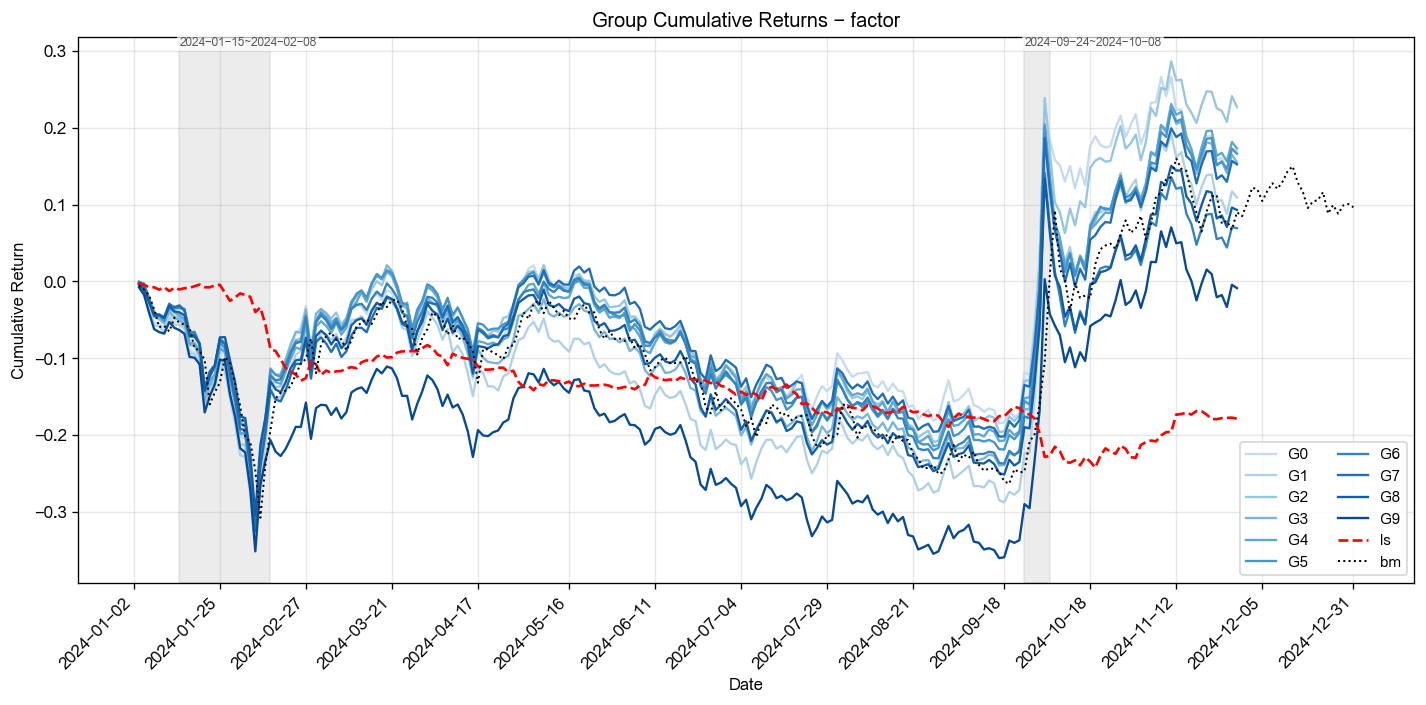
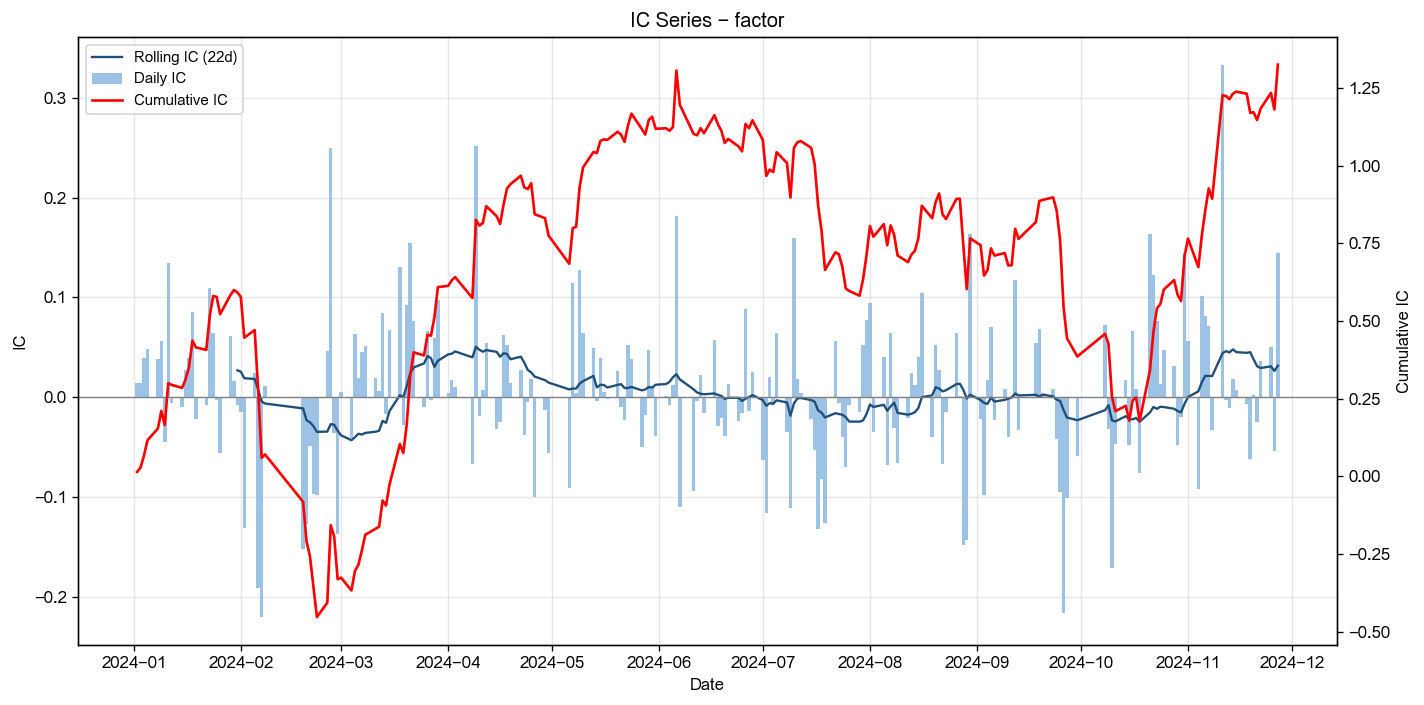
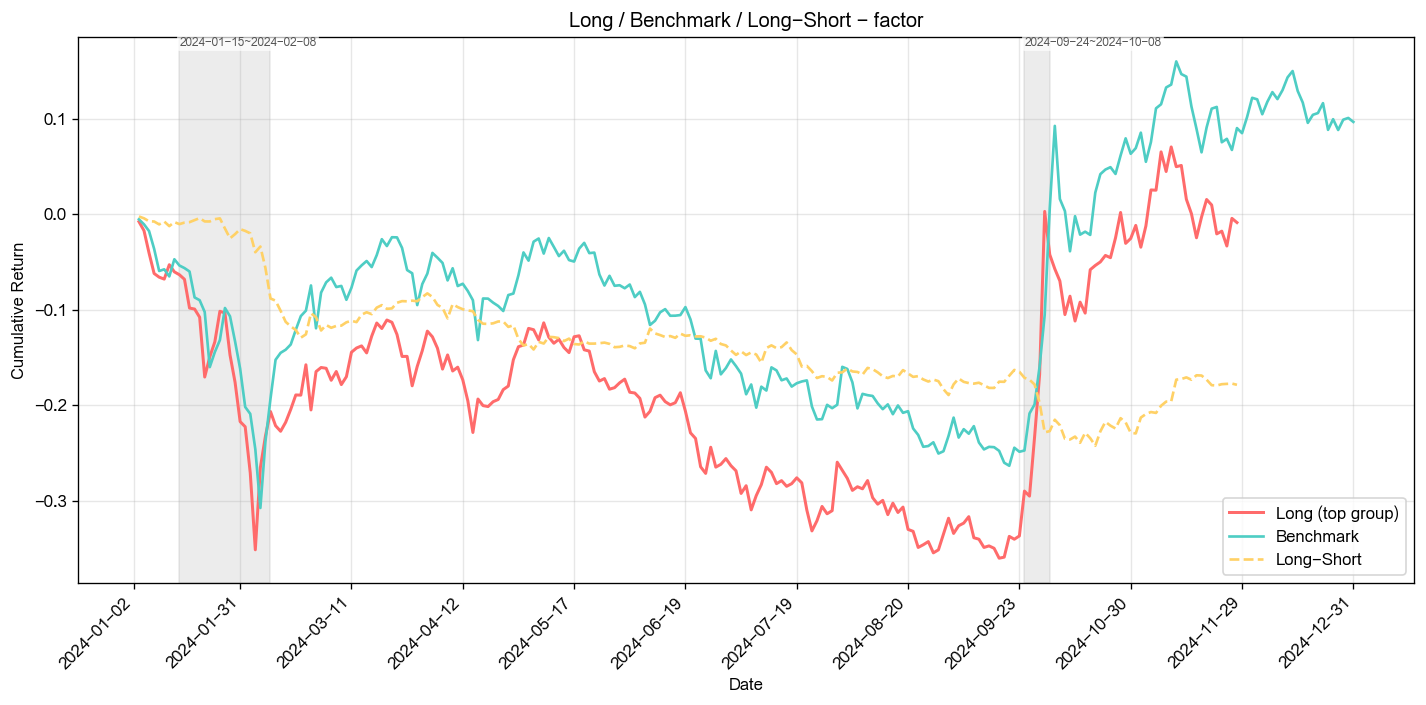
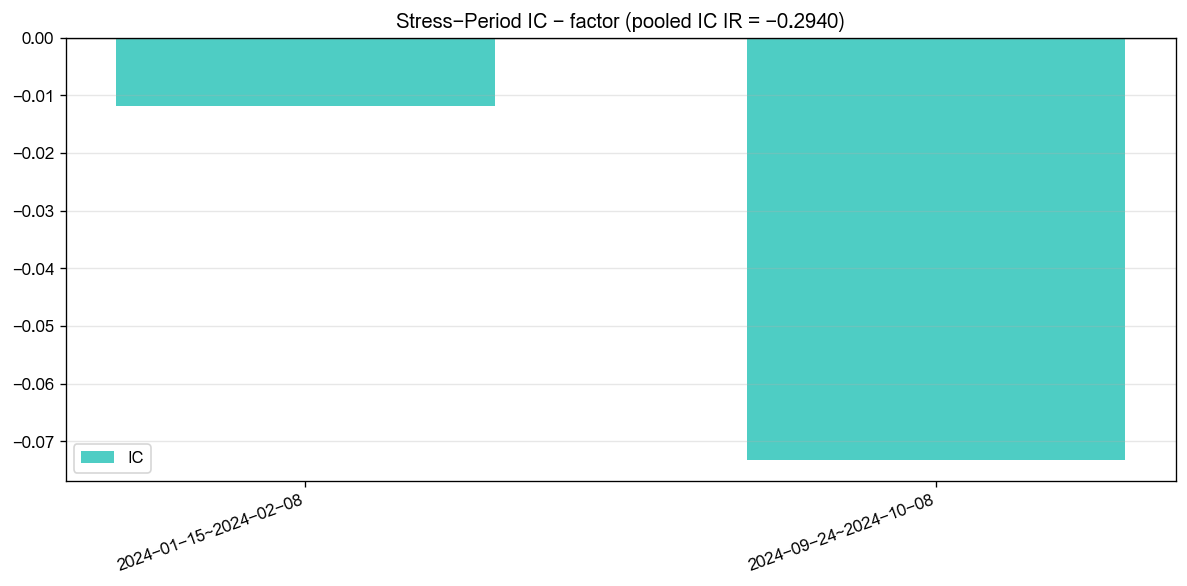
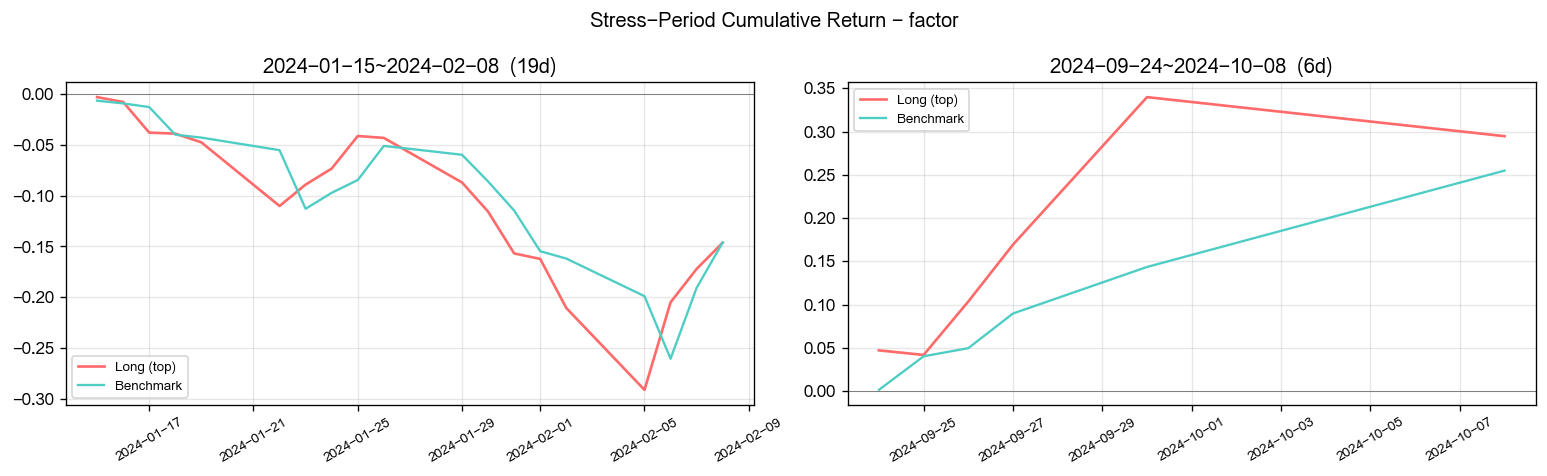

[2026-07-06 10:53:06] [info     ] ========== 因子池回归 ==========
[2026-07-06 10:53:07] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-06 10:53:12] [info     ] 获取收益率数据, 耗时: 5.697 秒
[2026-07-06 10:53:15] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.7804 秒
[2026-07-06 10:53:15] [info     ] 统计 回归结果, 耗时: 0.0096 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9303,0.0446,0.0231,1.0000
2,amount,1.7029,0.0185,0.0108,1.0000
3,netflow_amount_rate_main,1.5472,0.0099,0.0064,1.0000
4,netflow_amount_main,1.5200,0.0252,0.0166,1.0000
5,gross_profit_rate_ttm,1.5059,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4463,0.0040,0.0028,0.8000
7,pb,1.4125,0.0097,0.0068,1.0000
8,bias_20,1.4122,0.0292,0.0207,0.9000
9,cci_14,1.3858,0.0338,0.0244,1.0000
10,factor,1.3124,0.0057,0.0043,0.9000

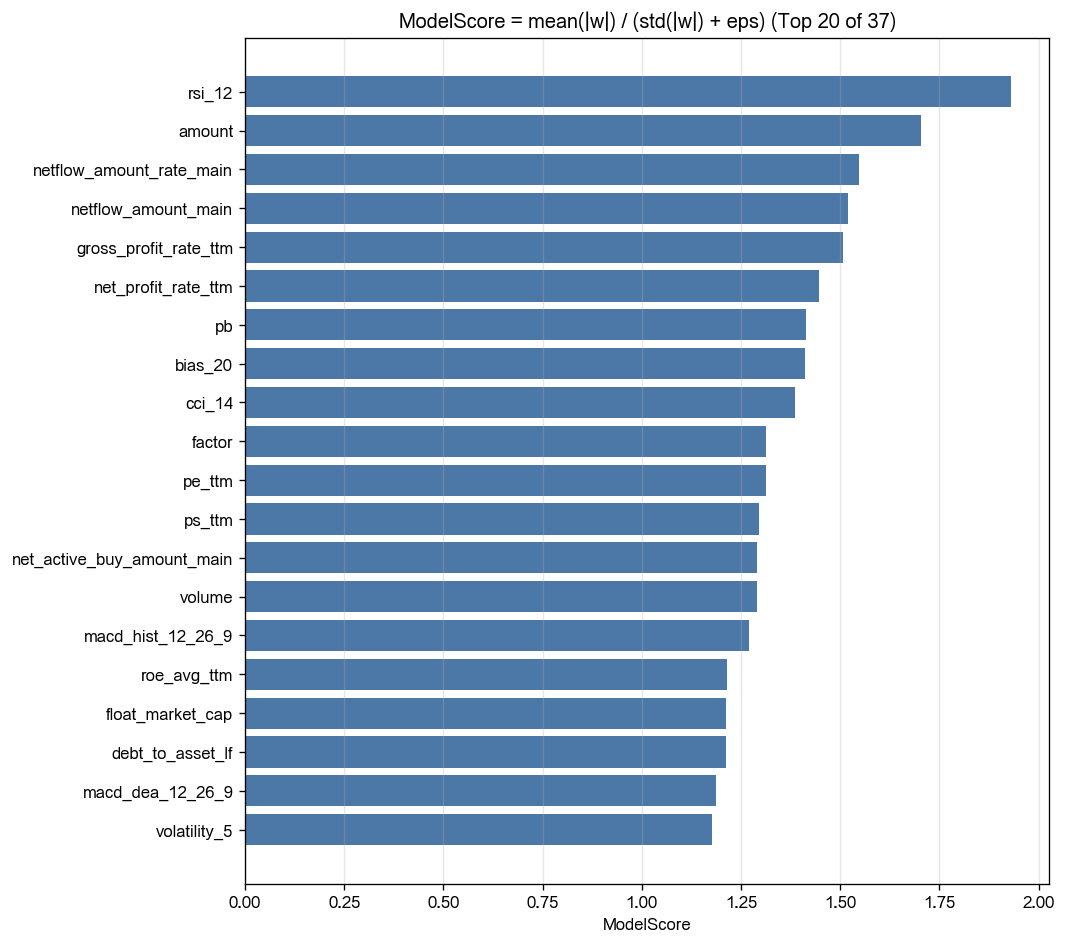
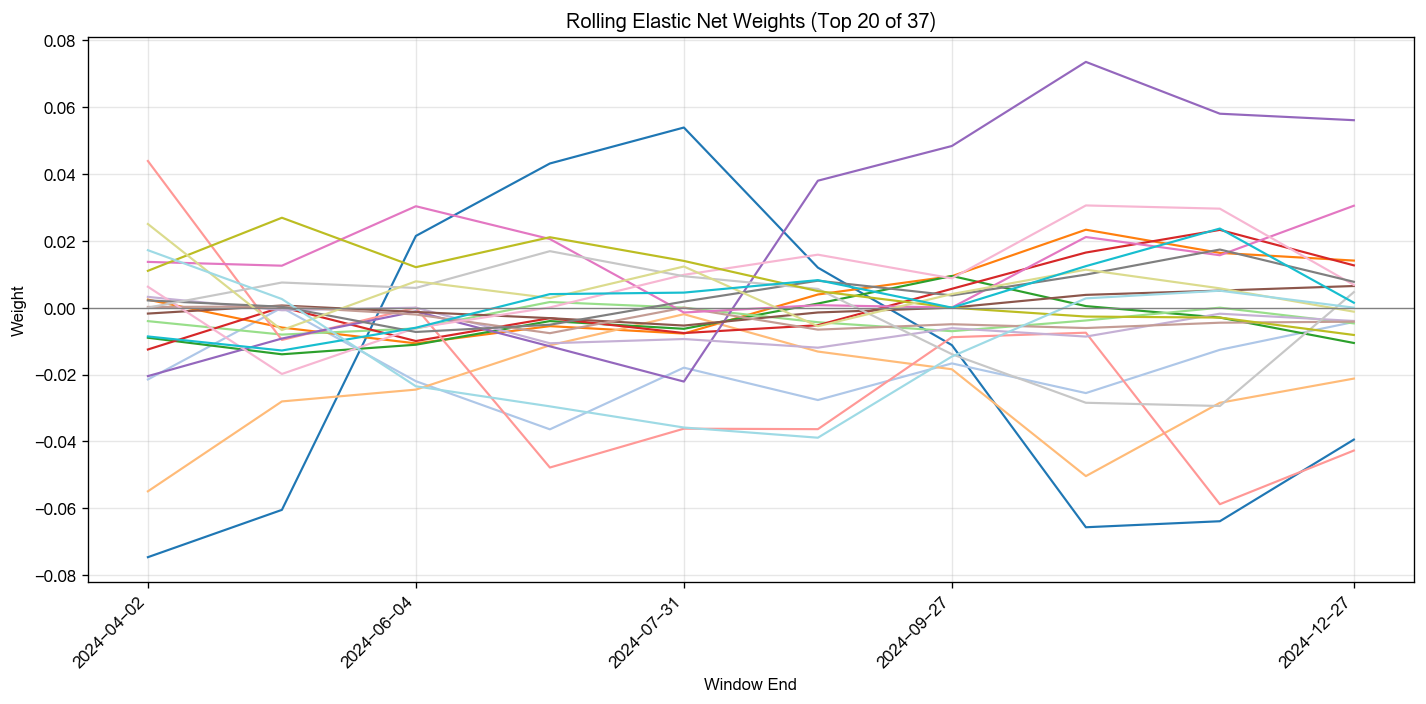
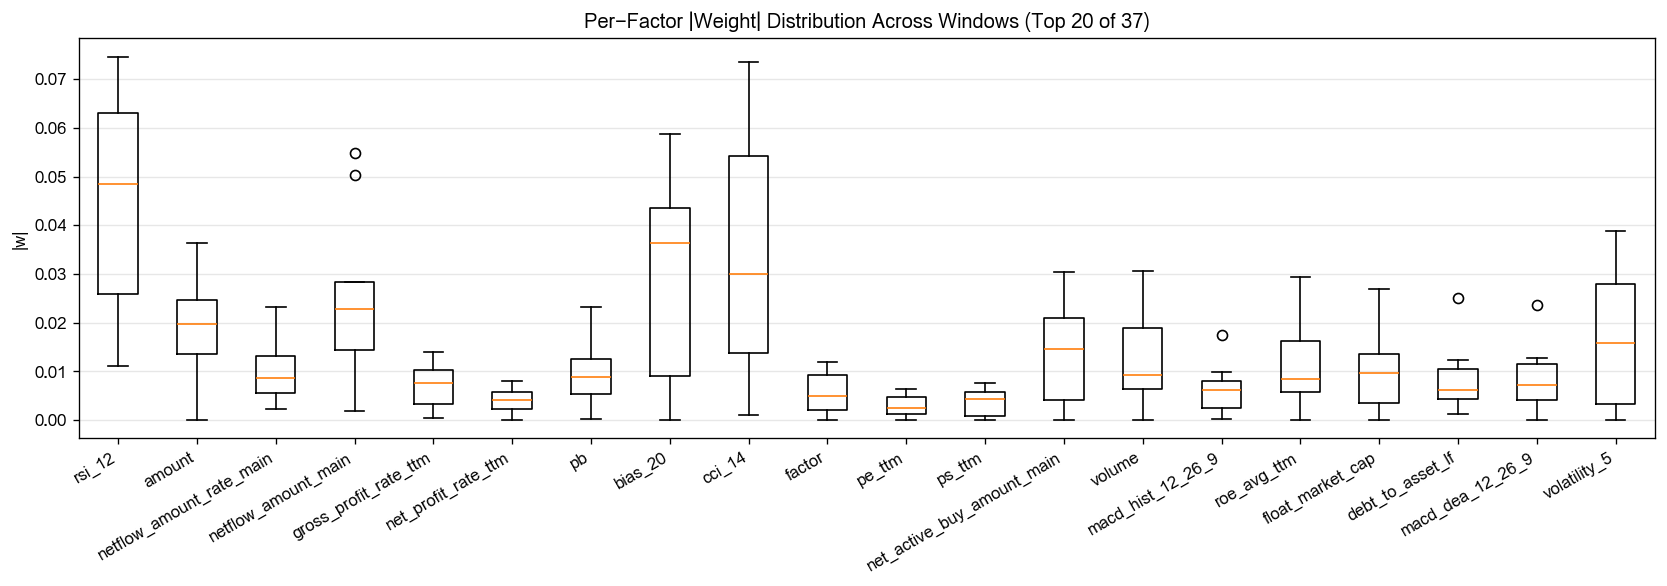
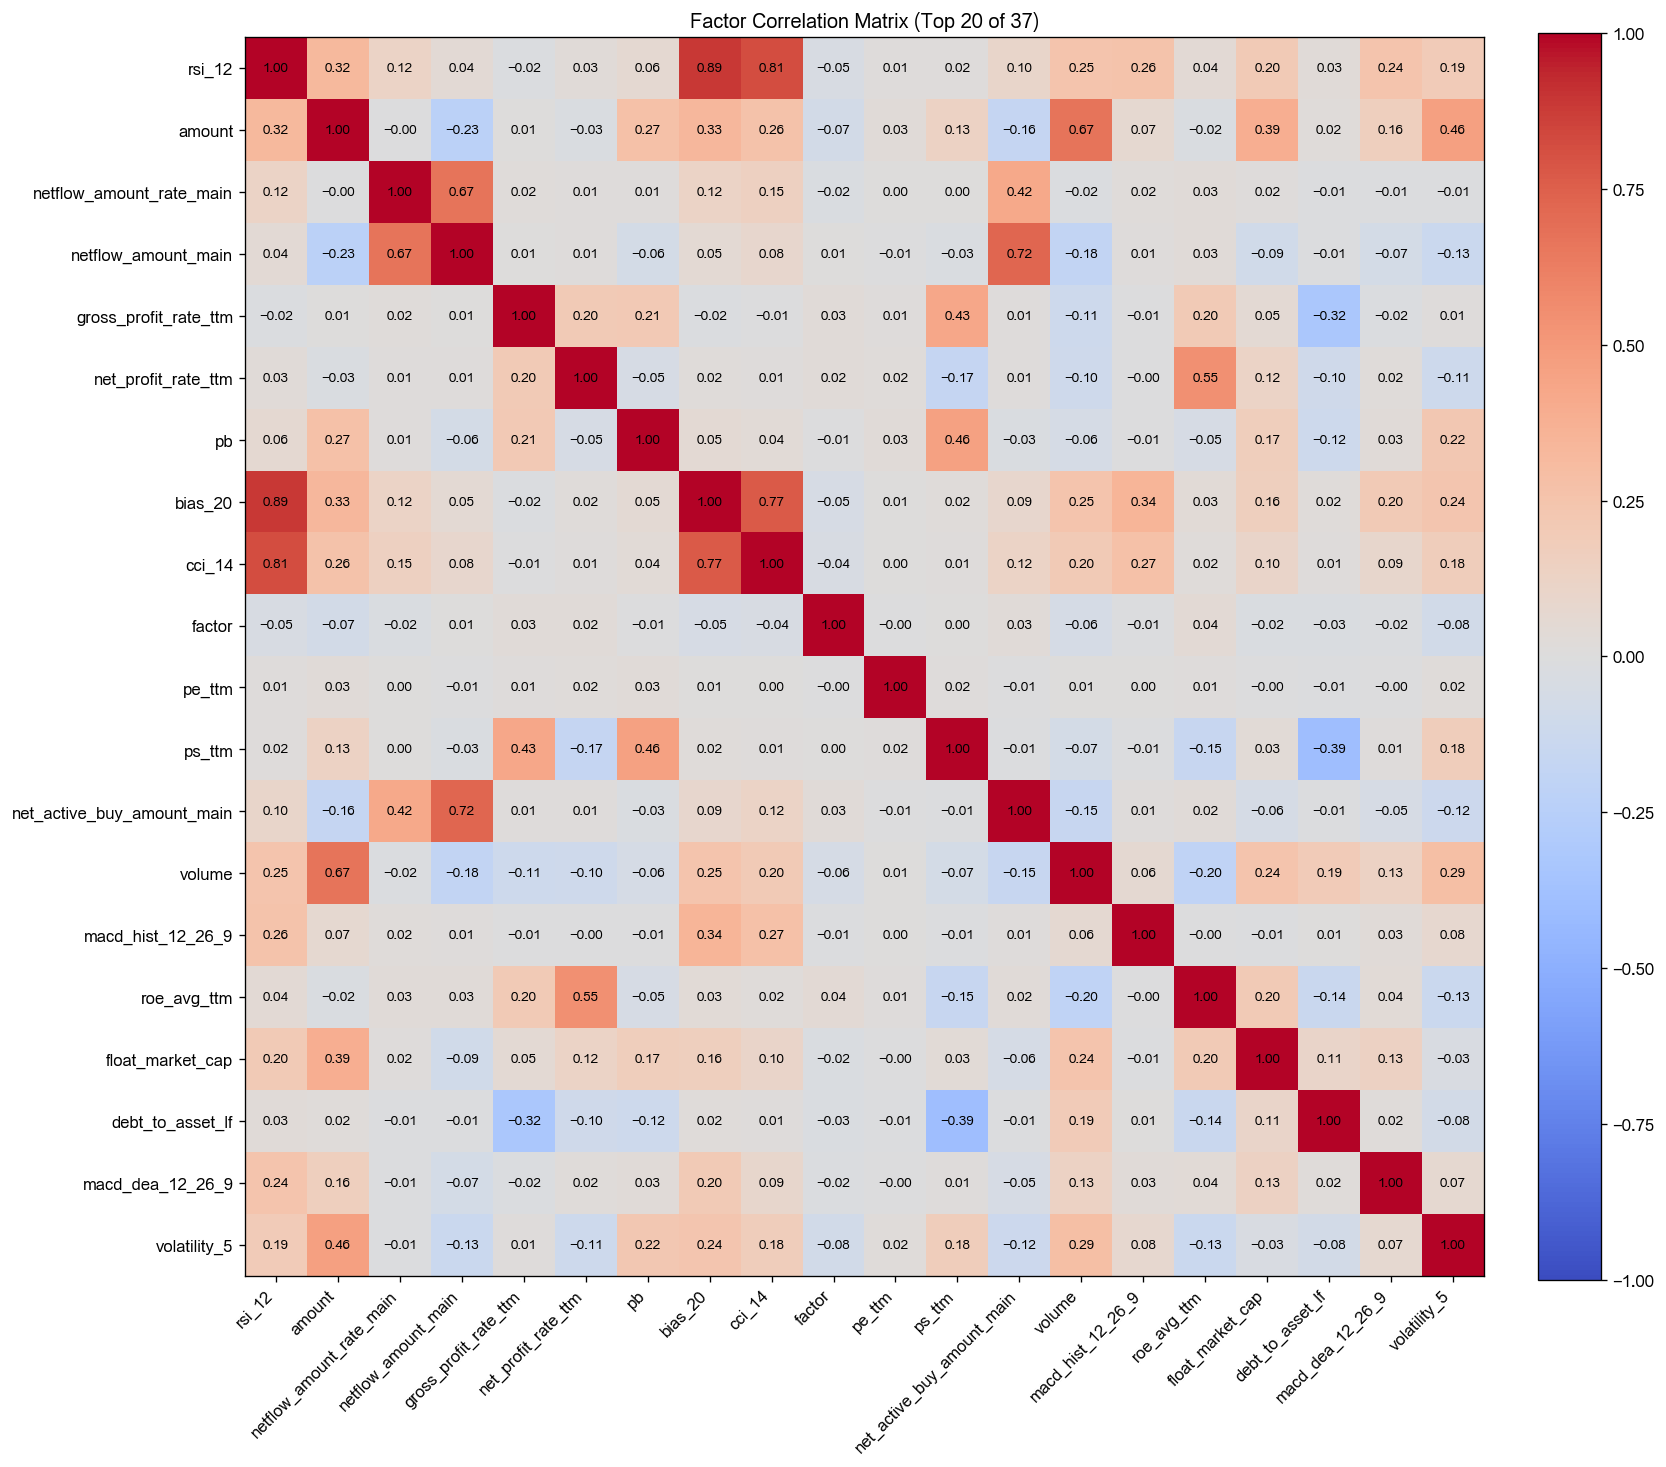

[2026-07-06 10:53:18] [warning  ] 返回的Outputs实例(size=35405214) 大于 64K, 将不会被缓存
[2026-07-06 10:53:18] [info     ] bigalpha_eval.v4 运行完成 [103.617s].


In [2]:
import dai
import pandas as pd
import numpy as np

def main(datasources, start_date, end_date):
    """
    尾盘失衡因子: 14:30后VWAP溢价 + 深度变化 + 价格动量 的复合
    只用已确认字段: close(=price), bid_volume1..5, ask_volume1..5
    """
    bar1m = datasources["bar1m"]

    sql = f"""
    WITH minute_data AS (
        SELECT
            date_trunc('day', date)::DATE AS date,
            instrument::STRING AS instrument,
            date::TIME AS time,
            close,
            volume,
            amount,
            bid_volume1, ask_volume1,
            bid_volume2, ask_volume2,
            bid_volume3, ask_volume3,
            bid_volume4, ask_volume4,
            bid_volume5, ask_volume5
        FROM {bar1m}
        WHERE date BETWEEN '{start_date}' AND '{end_date}'
    ),
    daily_agg AS (
        SELECT
            date,
            instrument,
            -- 全日VWAP
            SUM(amount) / NULLIF(SUM(volume), 0) AS vwap_full,
            -- 尾盘VWAP (14:30后)
            SUM(CASE WHEN time >= '14:30:00' THEN amount ELSE 0 END)
                / NULLIF(SUM(CASE WHEN time >= '14:30:00' THEN volume ELSE 0 END), 0) AS vwap_tail,
            -- 尾盘收盘价
            ARG_MAX(CASE WHEN time >= '14:30:00' THEN close ELSE NULL END,
                    CASE WHEN time >= '14:30:00' THEN date ELSE NULL END) AS close_price,
            -- 尾盘开盘价(14:30时刻)
            ARG_MIN(CASE WHEN time >= '14:30:00' THEN close ELSE NULL END,
                    CASE WHEN time >= '14:30:00' THEN date ELSE NULL END) AS tail_open_price,
            -- 全日深度比 (手动5档计算)
            AVG(
                (bid_volume1+bid_volume2+bid_volume3+bid_volume4+bid_volume5)
                / NULLIF(ask_volume1+ask_volume2+ask_volume3+ask_volume4+ask_volume5, 0)
            ) AS full_depth_ratio,
            -- 尾盘深度比
            AVG(CASE WHEN time >= '14:30:00' THEN
                (bid_volume1+bid_volume2+bid_volume3+bid_volume4+bid_volume5)
                / NULLIF(ask_volume1+ask_volume2+ask_volume3+ask_volume4+ask_volume5, 0)
            ELSE NULL END) AS tail_depth_ratio
        FROM minute_data
        GROUP BY date, instrument
    )
    SELECT
        date,
        instrument,
        (vwap_tail / NULLIF(vwap_full, 0) - 1.0) * 0.4
            + (tail_depth_ratio - full_depth_ratio) * 0.3
            + (close_price / NULLIF(tail_open_price, 0) - 1.0) * 0.3 AS factor
    FROM daily_agg
    """

    df = dai.query(sql, filters={"date": [start_date, end_date]}, compression=True).df()

    stk_pool = dai.query(f"""
        SELECT date::DATE AS date, instrument::STRING AS instrument
        FROM bigalpha_2026_instruments
        WHERE date BETWEEN '{start_date}' AND '{end_date}'
    """, filters={"date": [start_date, end_date]}, compression=True).df()

    result = pd.merge(stk_pool, df, on=['date', 'instrument'], how='left')
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result['factor'] = result.groupby('date')['factor'].transform(lambda x: x.fillna(x.median()))
    result['factor'] = result['factor'].fillna(0)

    return result[['date', 'instrument', 'factor']].copy()


if __name__ == "__main__":
    from bigmodule import M

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    factor_data = main(datasources, start_date, end_date)

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
